# 2D Interpolation - Bi-linear Shape Functions

In this notebook, we will explore two-dimensional interpolation using bi-linear shape functions for a quadrilateral element. We will translate the concepts and MATLAB code from [fea.ju.se/Interpolation2D/](https://fea.ju.se/Interpolation2D/) into Python, utilizing libraries like NumPy, Matplotlib, and MechanicsKit.

Give som field in the *nodal* values of an element we can compute values somewhere inside the element using the basis functions as an interpolant. This section shows how to do this and how the choice of basis functions effect the interpolation accuracy.

![Bi-Cubic interpolation of real measurements from a 3D printer heated bed](graphics/Inerpolation2D_Bi-Cubic_Interpolation.png){width=400, fig-align="center"}

In [1]:
# | code-fold: false
import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp
from mechanicskit import la

# For nice plots
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

## Visualizing the Element and Nodal Values

We start by defining the geometry of a single quadrilateral element with four nodes. The coordinates of the nodes are stored in a matrix `P`, and a scalar value (e.g., temperature) at each node is stored in a vector `U`.

In [2]:
# | code-fold: false
# Nodal coordinates (4 nodes, 2 dimensions)
P = np.array([[0.0, 0.0],   # Node 1
              [1.0, 0.0],   # Node 2
              [0.9, 1.0],   # Node 3
              [-0.1, 1.2]]) # Node 4

# Nodal values (e.g., temperature)
U = np.array([20, 30, 40, 25])

# Element connectivity (a single quad element)
# Using 1-based indexing as is common in FEM
faces = np.array([[1, 2, 3, 4]])

We can visualize this element and the scalar field using the `patch` function from `MechanicsKit`. By setting `FaceColor` to `'interp'`, the function will interpolate the nodal values (`CData`) across the face of the element.

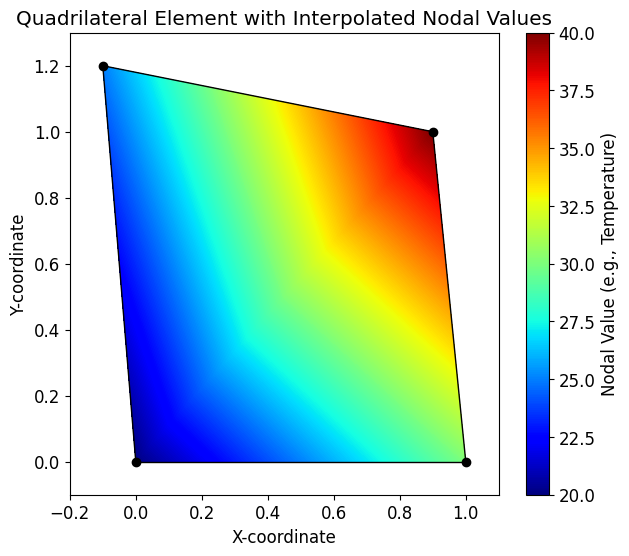

In [3]:
# | code-fold: true
fig, ax = plt.subplots(figsize=(7, 6))

mk.patch(Faces=faces, Vertices=P, CData=U, FaceColor='interp', cmap='jet')

mk.colorbar(label='Nodal Value (e.g., Temperature)')

ax.plot(P[:, 0], P[:, 1], 'ok', markerfacecolor='k')

ax.set(aspect='equal',
       title='Quadrilateral Element with Interpolated Nodal Values',
       xlabel='X-coordinate',
       ylabel='Y-coordinate',
       xlim=[-0.2, 1.1],
       ylim=[-0.1, 1.3])
plt.show()

## Basis Functions in Parametric Coordinates

Now, we want to know what the value $u_h$ is inside the element at the point $(x,y)$.

The interpolation is performed using basis functions (or shape functions) defined in a local, parametric coordinate system (ξ, η), which ranges from 0 to 1.
For the quadrilateral element, the bi-linear basis functions defined in the parametric coordinates $\xi, \eta \in [0,1]$:

$$
\varphi(\xi, \eta)=\left[\begin{array}{c}
(1-\xi)(1-\eta) \\
\xi(1-\eta) \\
\xi \eta \\
\eta(1-\xi)
\end{array}\right]^{\mathsf{T}}
$$

![Interpolation in 2D parametric space](graphics/Interpolation2D_ParametricSpace.png){width=400, fig-align="center"}

In [4]:
# | code-fold: false
xi, eta = sp.symbols('xi eta')

# Define the basis functions as a list of symbolic expressions
phi_sym_list = [
    (1 - xi) * (1 - eta),  # phi1
    xi * (1 - eta),        # phi2
    xi * eta,              # phi3
    (1 - xi) * eta         # phi4
]

# Convert to a sympy Matrix for easier manipulation
phi_sym = sp.Matrix(phi_sym_list).T # Transpose to a row vector

In [5]:
#| echo: false
mk.display_labeled_latex(r"\varphi(\xi, \eta)=", phi_sym.T)

<IPython.core.display.Latex object>

## Interpolating the Scalar Field

The interpolated value `Uh` at any point $(ξ, η)$ inside the element is a weighted average of the nodal values `U`, where the weights are the basis functions:

$$ U_h(\xi, \eta) = \sum_{i=1}^{4} \varphi_i(\xi, \eta) U_i = \boldsymbol{\varphi}(\xi, \eta) \mathbf{U} $$

In [6]:
# | code-fold: false
# Perform the symbolic interpolation
U_sym = sp.Matrix(U)
Uh_sym = phi_sym * U_sym
Uh_sym = sp.simplify(Uh_sym[0])


In [7]:
#| echo: false
mk.display_labeled_latex(r"U_h(\xi, \eta)=",Uh_sym)

<IPython.core.display.Latex object>

Ok, so now we can evaluate the values somwhere inside element, but only in parametric coordinates. For instance in the midpoint we have $u_h(\xi=0.5, \eta=0.5)$:

In [8]:
# | code-fold: false
Uh_sym.subs({xi:0.5, eta:0.5})

28.7500000000000

## Mapping from Physical to Parametric Coordinates - Affine elements

The issue is when we actually want the values $u_h$ as functions of the coordinates $x, y$, i.e., $u(x, y)$, we need to solve a system of equations which, depending on the geometry of the element (the coordinates $\mathbf{P}$ ), will be either linear or non-linear. For instance when $\mathbf{P}$ is affine:

In [9]:
# | code-fold: false
P = np.array([[0,0],
              [2,0],
              [2,1],
              [0,1]])

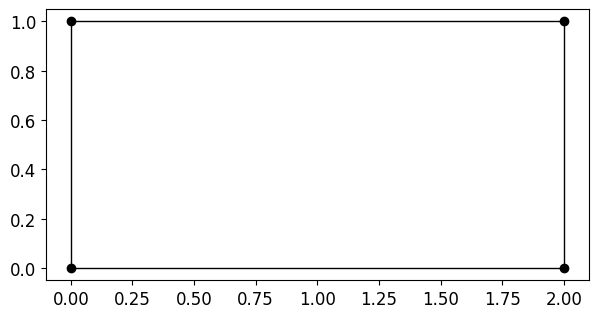

In [10]:
# | code-fold: false

fig, ax = plt.subplots(figsize=(7, 6))
mk.patch(Faces=np.array([[1,2,3,4]]), Vertices=P, FaceColor='w')
ax.plot(P[:, 0], P[:, 1], 'ok', markerfacecolor='k')
ax.set(aspect='equal')
plt.show()

We want to solve the linear system:

$$
\boldsymbol{\varphi}(\xi, \eta) \mathbf{P} = \left[\begin{array}{c}
x \\
y
\end{array}\right]
$$

for $\xi(x, y)$  and  $\eta(x, y)$.

In [11]:
# | code-fold: false
x,y = sp.symbols('x y')

eqs = sp.Eq((phi_sym*P).T, sp.Matrix([[x, y]]).T ).simplify()

In [12]:
#| echo: false
mk.display_labeled_latex(r"",eqs)

<IPython.core.display.Latex object>

We see that this system is trivial to solve for affine elements:

In [13]:
# | code-fold: false
sol = sp.solve(eqs, (xi, eta))

In [14]:
#| echo: false
mk.display_labeled_latex(r"\begin{bmatrix}\xi\\ \eta \end{bmatrix}=", sp.Matrix([sol[xi], sol[eta]]))

<IPython.core.display.Latex object>

We can then substitute $\xi(x, y)$ and $\eta(x, y)$ into $\boldsymbol \varphi(\xi, \eta)$ to get the basis functions as functions of $x$ and $y$, $\boldsymbol \varphi  (x, y)$:

In [15]:
# | code-fold: false
phi_sym_1 = phi_sym.subs({xi: sol[xi], eta: sol[eta]})
phi_sym_1 = sp.simplify(phi_sym_1).T

In [16]:
#| echo: false
mk.display_labeled_latex(r"\boldsymbol{\varphi}(x,y)=", phi_sym_1)

<IPython.core.display.Latex object>

Which we can use as an interpolant for $u_h(x, y)$:

$$ \boxed{ u_h(x, y) = \boldsymbol{\varphi}(x, y) \mathbf{U} } $$

## Mapping from Physical to Parametric Coordinates - Non-Affine elements

If, however, the element is non-affine, e.g.,

In [17]:
# | code-fold: false
P = np.array([[0,0],
              [1,0],
              [0.9,1],
              [-0.1,1.2]])

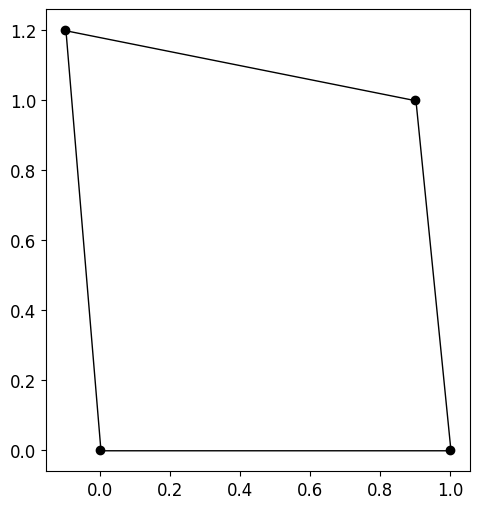

In [18]:
# | code-fold: true

fig, ax = plt.subplots(figsize=(7, 6))
mk.patch(Faces=np.array([[1,2,3,4]]), Vertices=P, FaceColor='w')
ax.plot(P[:, 0], P[:, 1], 'ok', markerfacecolor='k')
ax.set(aspect='equal')
plt.show()

using $\varphi(\xi, \eta) \mathbf{P}=[x, y]$ and solving again for  $\xi(x, y)$  and  $\eta(x, y)$  we get the non-linear system of equations

In [19]:
# | code-fold: false
x, y = sp.symbols('x y')
P_sym = sp.Matrix(P)

# System of equations: phi * P = [x, y]
eqs = sp.Eq( (phi_sym * P_sym).T, sp.Matrix([[x, y]]).T ).simplify()
eqs

Eq(Matrix([
[x],
[y]]), Matrix([
[ -0.1*eta + 1.0*xi],
[eta*(1.2 - 0.2*xi)]]))

notice how we can not formulate a system of the form $\mathbf A \xi + \mathbf B \eta + \mathbf C = 0$. We can however solve this system using sympy:

In [20]:
# | code-fold: false
sol = sp.solve(eqs, (xi, eta), dict=True)

In [21]:
#| echo: false
mk.display_labeled_latex(r"\begin{bmatrix}\xi_{1}\\ \eta_{1} \end{bmatrix}=", sp.Matrix([sol[0][xi], sol[0][eta]]))

<IPython.core.display.Latex object>

In [22]:
#| echo: false
mk.display_labeled_latex(r"\begin{bmatrix}\xi_{2}\\ \eta_{2} \end{bmatrix}=", sp.Matrix([sol[1][xi], sol[1][eta]]))

<IPython.core.display.Latex object>

here, in the two solutions $\xi_1(x, y)$ and $\xi_2(x, y)$, only one is within the valid parametric space $\xi, \eta \in[0,1]$, which is $\xi_1$ and $\eta_1$ (after testing).

![Non-linear mapping. For non-affine elements we get two solutions, where one lies inside the element and one is not valid and should be discarded.](graphics/Interpolation2D_NonLinearMapping.png){width=400, fig-align="center"}

In [23]:
# | code-fold: false
xi1 = sol[0][xi]
eta1 = sol[0][eta]
phi_sym_xy = phi_sym.subs({xi: xi1, eta: eta1})
phi_sym_xy = sp.simplify(phi_sym_xy)

In [24]:
#| echo: false
mk.display_labeled_latex(r"\boldsymbol \varphi(x, y)=", phi_sym_xy.T)

<IPython.core.display.Latex object>

In [25]:
# | code-fold: false
phi_np = sp.lambdify((x, y), phi_sym_xy, 'numpy')
phi_np(P[:,0], P[:,1])[0] | la

Here we just verify that the mapping is correct by evaluating the corner points. We get back an identity matrix as expected. Since the basis functions are one in "their" nodes and zero in all other nodes.

::: {.callout-note}
Obviously it is not efficient to solve a non-linear system every time we want to evaluate the interpolant at a new point $(x,y)$. Which is why we prefer to work in the parametric space is we can! 
:::

For our problem where we want to generate the function $u_h(x, y)$, we can now use $u_h(x, y)=\varphi(x, y) \mathbf{U}$

In [26]:
# | code-fold: false
U_sym

Matrix([
[20],
[30],
[40],
[25]])

In [37]:
# | code-fold: false
phi_sym_xy.T

Matrix([
[-25.5*x - 5.0*y - 24.5*sqrt(x**2 - 12.0*x - 2.0*y + 36.0) + 148.0],
[ 30.5*x + 5.0*y + 29.5*sqrt(x**2 - 12.0*x - 2.0*y + 36.0) - 177.0],
[-30.0*x - 5.0*y - 30.0*sqrt(x**2 - 12.0*x - 2.0*y + 36.0) + 180.0],
[ 25.0*x + 5.0*y + 25.0*sqrt(x**2 - 12.0*x - 2.0*y + 36.0) - 150.0]])

In [28]:
# | code-fold: false
x, y = sp.symbols('x y')
Uh_sym_xy = (phi_sym_xy * U_sym)[0]


In [29]:
#| echo: false
mk.display_labeled_latex(r"U_h(x, y)=", Uh_sym_xy)

<IPython.core.display.Latex object>

Evaluating this function at a known point, e.g., $x=0$, $y=0$, we get back the expected nodal value $U=20$.

In [30]:
# | code-fold: false
Uh_sym_xy.subs({x:0.0, y:0.0})

20.0000000000000

## Visualizing the Interpolated Field

Now we can visualize the interpolated scalar field $U_h$ over the physical domain of the element. We create a grid of points in the parametric (ξ, η) space, map these points to the physical (x, y) space, and evaluate the interpolated function $U_h$ at each point.

In [31]:
# | code-fold: false
# Create a grid in the parametric space
N = 100
xi_vals = np.linspace(0, 1, N)
eta_vals = np.linspace(0, 1, N)
Xi, Eta = np.meshgrid(xi_vals, eta_vals)

# Lambdify the symbolic basis functions for numerical evaluation
# We need to evaluate phi for each point in the grid
phi_func = sp.lambdify((xi, eta), phi_sym, 'numpy')

# Evaluate - returns shape (1, 4) for each point, but numpy broadcasts
Phi = phi_func(Xi.ravel(), Eta.ravel())  # Shape: (1, 4, N*N)
Phi = np.squeeze(Phi)  # Now shape: (4, N*N)

In [32]:
#| echo: false
mk.display_labeled_latex(r"\boldsymbol \varphi (\boldsymbol \xi, \boldsymbol \eta)=",Phi,show_shape=True)

<IPython.core.display.Latex object>

In [33]:
# | code-fold: false
UH = (Phi.T @ U).reshape(N, N)

In [34]:
#| echo: false
mk.display_labeled_latex(r"U_h=",UH,show_shape=True)

<IPython.core.display.Latex object>

In [35]:
# | code-fold: false
PP = Phi.T @ P # Shape: (N*N, 2)
X = PP[:, 0].reshape(N, N)
Y = PP[:, 1].reshape(N, N)

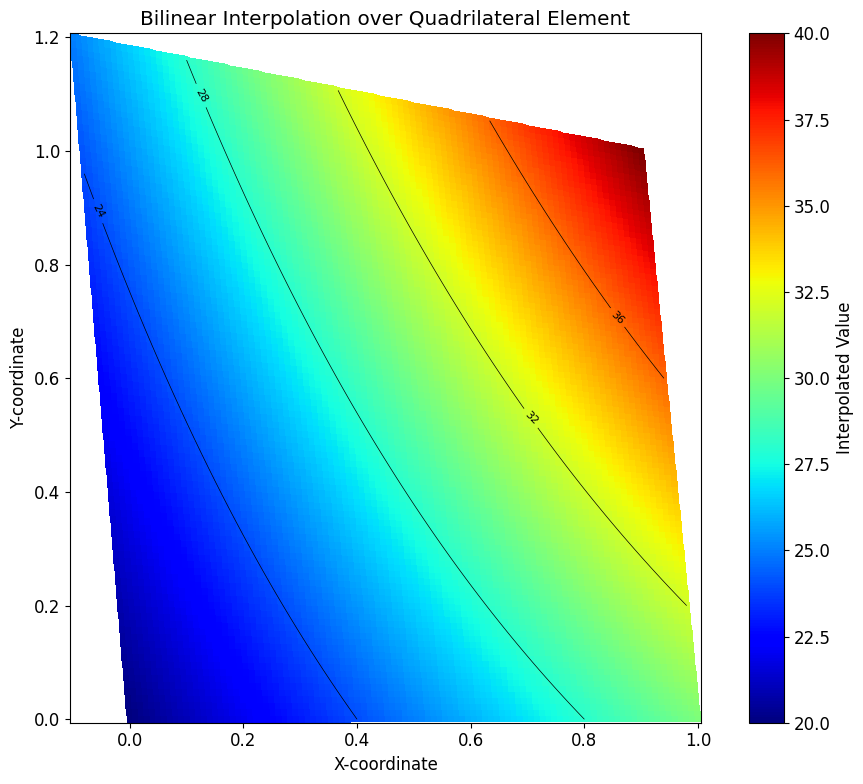

In [36]:
# | code-fold: false
# Plot
fig, ax = plt.subplots(figsize=(10, 8))
surf = ax.pcolormesh(X, Y, UH, cmap='jet', shading='auto')
contours = ax.contour(X, Y, UH, levels=5, colors='k', linewidths=0.5)
ax.clabel(contours, inline=True, fontsize=8)
ax.set_aspect('equal')
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Y-coordinate')
ax.set_title('Bilinear Interpolation over Quadrilateral Element')
plt.colorbar(surf, ax=ax, label='Interpolated Value')
plt.tight_layout()
plt.show()